In [2]:
import sqlite3
# db_path = '/Volumes/Lory SD/NOTCH_MSM_IA/EXP_3/Results/NOTCH_MSM_Run2.db'
db_path = '/Volumes/Lory SD/NOTCH_MSM_IA/EXP_4/Results/NOTCH_MSM_Run3.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

cursor.execute('SELECT name FROM sqlite_master WHERE type="table";')
tables = cursor.fetchall()
for table_name in tables:
    print(table_name[0])


Experiment
sqlite_sequence
Experiment_Properties
Per_Cell
Per_CellObjExp
Per_CellObjExp_ROI
Per_CellsObj
Per_Cytoplasm
Per_Nuclei
Per_Image
Per_Experiment
Per_RelationshipTypes
Per_Relationships


In [3]:
# Get the Per_Nuclei table and put in a PD DataFrame
import pandas as pd
per_nuclei_df = pd.read_sql_query('SELECT * FROM Per_Nuclei', conn)
#Print DF columns containing 'Mean'



In [3]:
mean_columns = [col for col in per_nuclei_df.columns if 'Mean' in col]
print(mean_columns)

['Nuclei_AreaShape_MeanRadius', 'Nuclei_Intensity_MeanIntensityEdge_HES', 'Nuclei_Intensity_MeanIntensityEdge_HEST', 'Nuclei_Intensity_MeanIntensityEdge_NOTCH', 'Nuclei_Intensity_MeanIntensityEdge_Nuclei', 'Nuclei_Intensity_MeanIntensity_HES', 'Nuclei_Intensity_MeanIntensity_HEST', 'Nuclei_Intensity_MeanIntensity_NOTCH', 'Nuclei_Intensity_MeanIntensity_Nuclei']


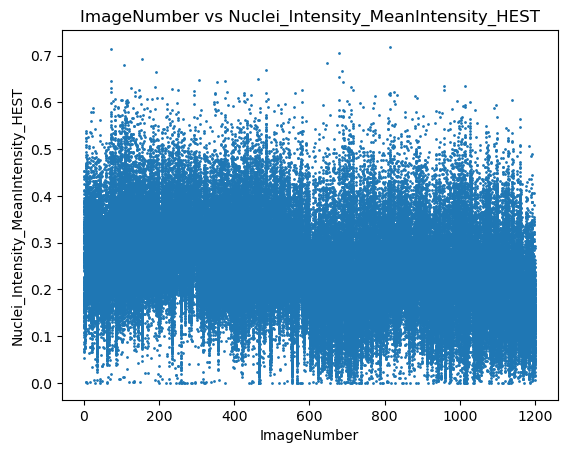

In [5]:
# Plot ImageNumber vs Nuclei_Intensity_MeanIntensity_HEST
import matplotlib.pyplot as plt
plt.scatter(per_nuclei_df['ImageNumber'], 
            per_nuclei_df['Nuclei_Intensity_MeanIntensity_HEST'], s=1)
plt.xlabel('ImageNumber')
plt.ylabel('Nuclei_Intensity_MeanIntensity_HEST')
plt.title('ImageNumber vs Nuclei_Intensity_MeanIntensity_HEST')
plt.show()

In [4]:
# txt_path='/Volumes/Lory SD/NOTCH_MSM_IA/EXP_3/ECPT_V3.6_NOTCH_Model.txt'
csv_path = '/Volumes/Lory SD/NOTCH_MSM_IA/EXP_4/Filelist.csv'
# Parse the file line by line and put each string line containing "NUC" in a list
celtype_lines = []
treatmode_lines = []
dose_lines = []

with open(csv_path, 'r') as file:
    for line in file:
        # Check if "NUC" is in the line
        if 'NUC' in line:
            # Check whether  have 1) HU/HA (celtype), 2) DA/DR (treatmode)
            # Put the value (e.g. "HU") in corresponding list
            if 'HU' in line:
                celtype_lines.append('HU')
            else:
                celtype_lines.append('HA')
            if 'DA' in line:
                treatmode_lines.append('DA')
            else:
                treatmode_lines.append('DR')
            # Extract the dose value before -NUC.tif and after the last underscore
            dose_value = line.split('_')[-1].split('-')[1]
            dose_lines.append(dose_value)
    print(dose_lines)

# Add new columns to per_nuclei_df where list index corresponds to ImageNumber-1
per_nuclei_df['CellType'] = per_nuclei_df['ImageNumber'].apply(lambda x: celtype_lines[x-1])
per_nuclei_df['TreatMode'] = per_nuclei_df['ImageNumber'].apply(lambda x: treatmode_lines[x-1])
per_nuclei_df['Dose'] = per_nuclei_df['ImageNumber'].apply(lambda x: dose_lines[x-1])
print(per_nuclei_df[['ImageNumber', 'CellType', 'TreatMode', 'Dose']].head())
                                                                                                         


['CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', 'CTRL', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.35', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '0.7', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5', '1.5'

125743
61942
36434


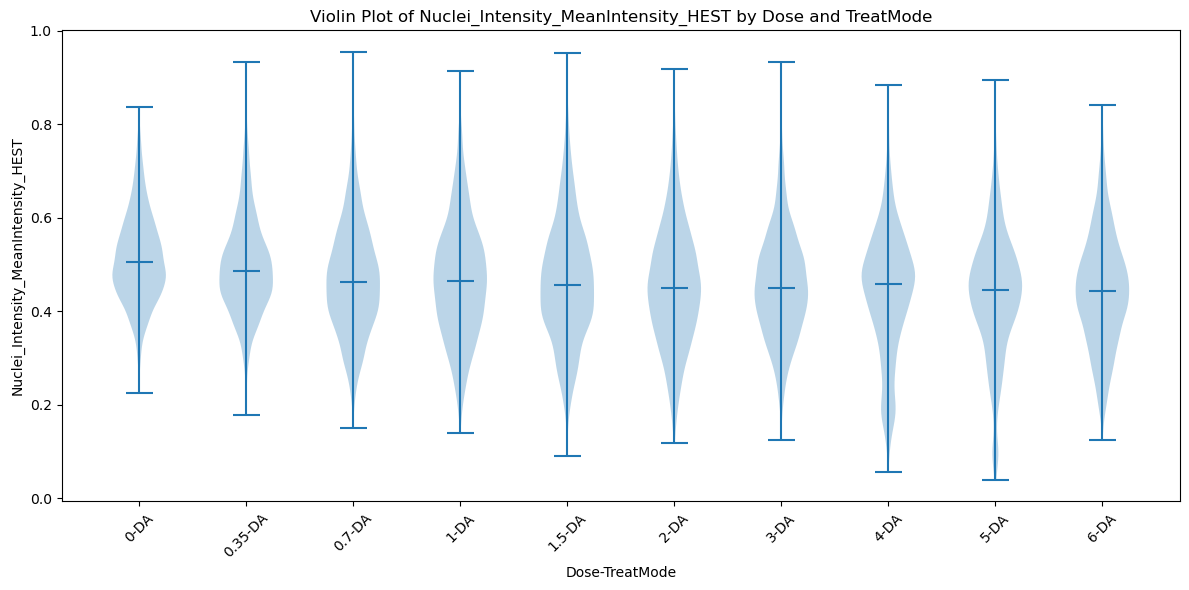

In [6]:
# Plot violin plots of Nuclei_Intensity_MeanIntensity_HEST for each dose and treatmode
# NO SEABORN!!
import matplotlib.pyplot as plt 
import numpy as np
import scipy.stats as stats
import pandas as pd

print(len(per_nuclei_df))

DA_df = per_nuclei_df[per_nuclei_df['TreatMode'] == 'DA']
print(len(DA_df))
DA_df = DA_df[DA_df['CellType'] == 'HU']
print(len(DA_df))
# Turn CTRL to dose 0
DA_df.loc[DA_df['Dose'] == 'CTRL', 'Dose'] = 0

# Drop all columns except Dose and Nuclei_Intensity_MeanIntensity_HEST
# DA_df = DA_df[['Dose', 'Nuclei_Intensity_MeanIntensity_HEST']]

# DA_df = DA_df[DA_df['Nuclei_Intensity_MeanIntensity_NOTCH'] < 0.999]

DR_df = per_nuclei_df[per_nuclei_df['TreatMode'] == 'DR']
DR_df = DR_df[DR_df['CellType'] == 'HU']
DR_df.loc[DR_df['Dose'] == 'CTRL', 'Dose'] = 0

# Prepare data for violin plots (make sure CTRL is first)
groups = DA_df.groupby('Dose')
# data = [group['Nuclei_Intensity_MeanIntensity_HEST'].values for name, group in groups]
data = [group['Nuclei_Intensity_MeanIntensity_HES'].values for name, group in groups]

labels = [f"{name}-DA" for name in groups.groups.keys()]
# Create violin plot
plt.figure(figsize=(12, 6))
plt.violinplot(data, showmeans=False, showmedians=True)
# # Overlay points
# for i, group in enumerate(data):
#     y = group
#     x = np.random.normal(i + 1, 0.04, size=len(y))  # Add some jitter to the x-axis
#     plt.plot(x, y, 'r.', alpha=0.2)
plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=45)
plt.xlabel('Dose-TreatMode')
plt.ylabel('Nuclei_Intensity_MeanIntensity_HEST')
plt.title('Violin Plot of Nuclei_Intensity_MeanIntensity_HEST by Dose and TreatMode')
plt.tight_layout()
plt.show()

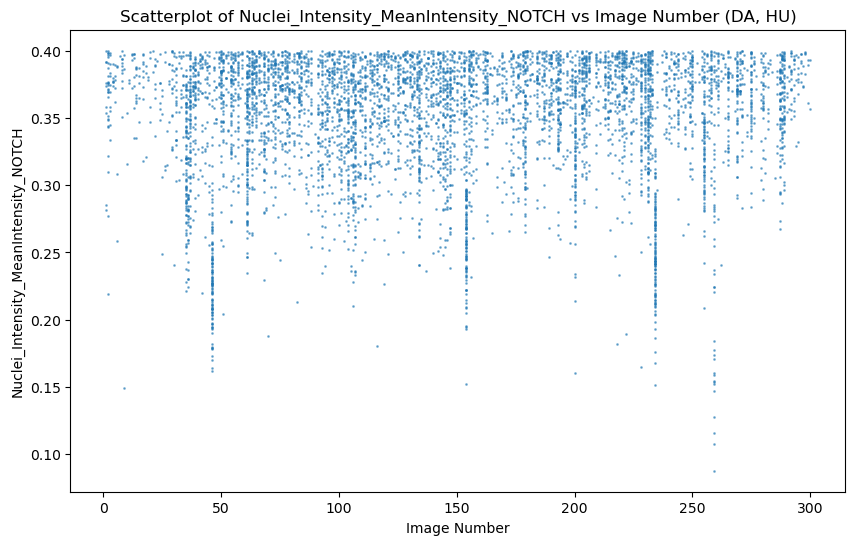

In [33]:
# Scatterplot of DA_df by image without grouping
plt.figure(figsize=(10, 6))
plt.scatter(DA_df['ImageNumber'], DA_df['Nuclei_Intensity_MeanIntensity_HES'],s=1 ,alpha=0.5)
plt.xlabel('Image Number')
plt.ylabel('Nuclei_Intensity_MeanIntensity_NOTCH')
# plt.xlim(0,29)
# plt.xlim(0,89)
plt.title('Scatterplot of Nuclei_Intensity_MeanIntensity_NOTCH vs Image Number (DA, HU)')
plt.show()

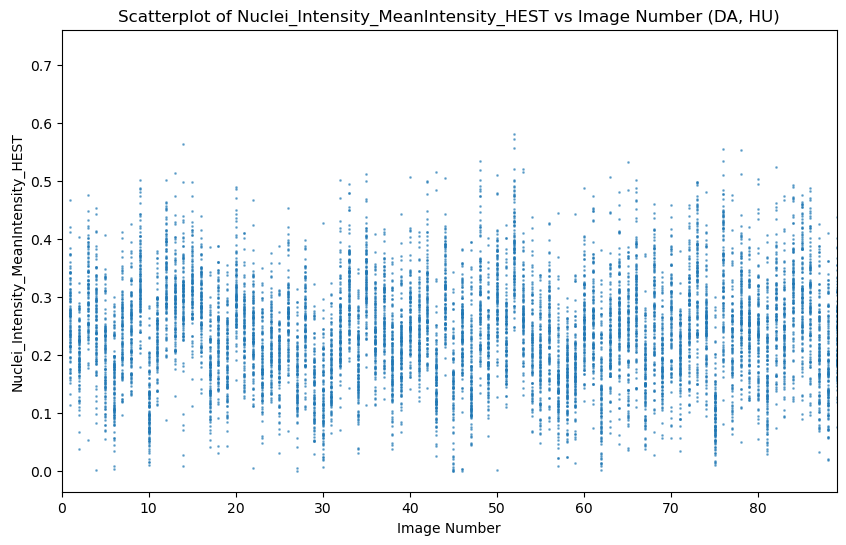

In [11]:
# Scatterplot of DA_df by image without grouping
plt.figure(figsize=(10, 6))
plt.scatter(DA_df['ImageNumber'], DA_df['Nuclei_Intensity_MeanIntensity_HEST'],s=1 ,alpha=0.5)
plt.xlabel('Image Number')
plt.ylabel('Nuclei_Intensity_MeanIntensity_HEST')
# plt.xlim(0,29)
plt.xlim(0,89)
plt.title('Scatterplot of Nuclei_Intensity_MeanIntensity_HEST vs Image Number (DA, HU)')
plt.show()



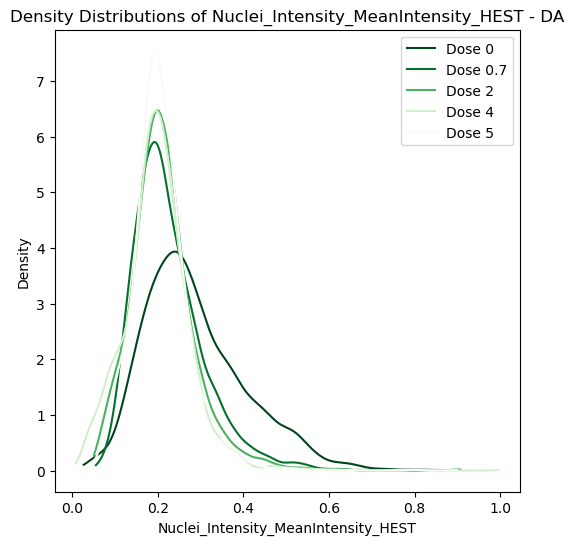

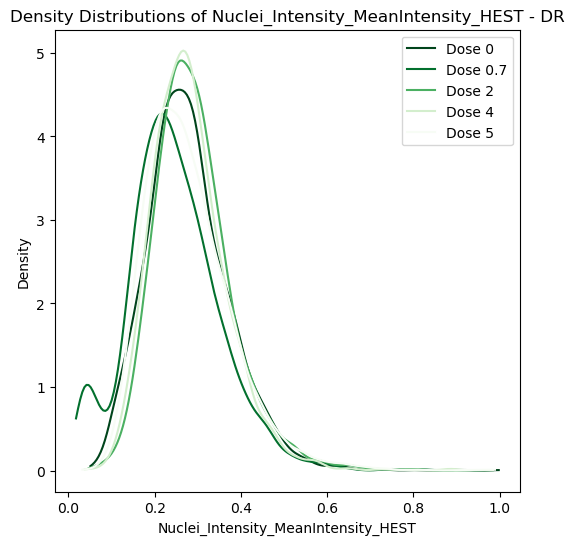

In [11]:
# Plot density distributions of Nuclei_Intensity_MeanIntensity_HEST for each dose for DA and DR treatmodes
# NO SEABORN!!
# Colourscale greens for doses
def plot_density_distributions(df, treat_mode):
    # Filter by dose values retain [0, 0.7, 2, 4, 5]
    df = df[df['Dose'].astype(str).isin(['0', '0.7', '2', '4', '5'])]
    groups = df.groupby('Dose')
    plt.figure(figsize=(6, 6))
    
    # Convert dose values to float for normalization
    dose_values = sorted([float(d) for d in groups.groups.keys()])
    max_dose = max(dose_values) if dose_values else 1
    
    for name, group in groups:
        data = group['Nuclei_Intensity_MeanIntensity_NOTCH'].values
        # Calculate density scaled to area=1
        density = stats.gaussian_kde(data)
        xs = np.linspace(min(data), max(data), 200)
        dose_float = float(name)
        color_norm = dose_float / max_dose
        plt.plot(xs, density(xs), label=f'Dose {name}', color=plt.cm.Greens_r(color_norm))
    plt.xlabel('Nuclei_Intensity_MeanIntensity_HEST')
    plt.ylabel('Density')
    plt.title(f'Density Distributions of Nuclei_Intensity_MeanIntensity_HEST - {treat_mode}')
    plt.legend()
    plt.show()

plot_density_distributions(DA_df, 'DA')
plot_density_distributions(DR_df, 'DR')



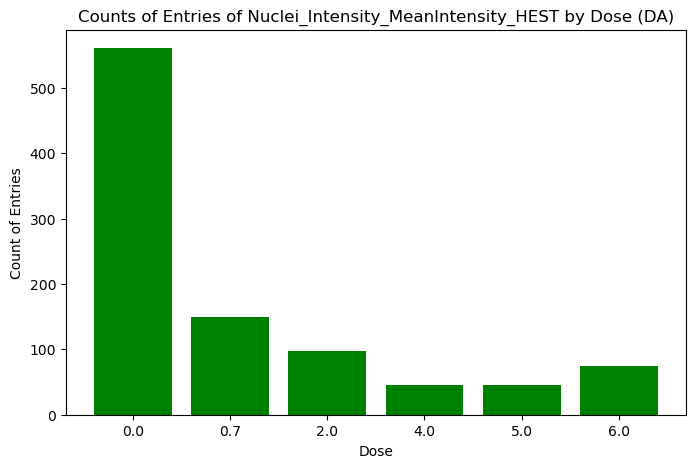

In [18]:
# Plot counts of entries with mean intensity HES > 0.5 by dose for DA treatmode  
c_df = DA_df[DA_df['Dose'].astype(str).isin(['0', '0.7', '2', '4', '5', '6'])]
dose_counts = c_df[c_df['Nuclei_Intensity_MeanIntensity_NOTCH'] > 0.4]['Dose'].value_counts()
# Convert index to float for sorting, then back to string for plotting
dose_counts.index = dose_counts.index.astype(float)
dose_counts = dose_counts.sort_index()
plt.figure(figsize=(8, 5))
plt.bar(dose_counts.index.astype(str), dose_counts.values, color='green')
plt.xlabel('Dose')
plt.ylabel('Count of Entries')
plt.title('Counts of Entries of Nuclei_Intensity_MeanIntensity_HEST by Dose (DA)')
plt.show()

**WRAP**
--------

In [1]:
import sqlite3
import pandas as pd

def retrieve_ECPT_data(db_path):
    conn = sqlite3.connect(db_path)
    per_image_df = pd.read_sql_query('SELECT * FROM Per_Image', conn)

    # Create a pd Df with ImageNumber, Image_Metadata_Cell, and Image_Metadata_Treatment
    image_metadata_df = per_image_df[['ImageNumber', 'Image_Metadata_Cell', 'Image_Metadata_Treatment']].copy()

    # Robustly split Image_Metadata_Cell into CellType and TreatMode, handling missing or malformed entries
    cell_split = image_metadata_df['Image_Metadata_Cell'].astype(str).str.split('_', expand=True)
    image_metadata_df['CellType'] = cell_split[0]
    image_metadata_df['TreatMode'] = 'none' if cell_split.shape[1] < 2 else cell_split[1]
    # Drop the Image_Metadata_Cell column
    image_metadata_df = image_metadata_df.drop(columns=['Image_Metadata_Cell'])
    # Rename Image_Metadata_Treatment to TreatTime
    image_metadata_df = image_metadata_df.rename(columns={'Image_Metadata_Treatment': 'Treat Time'})
    # Debug print to check for NaNs
    print(image_metadata_df.head())

    # Retrieve the per_nuclei_df
    per_nuclei_df = pd.read_sql_query('SELECT * FROM Per_Nuclei', conn)
    # Broadcast the image_metadata_df to per_nuclei_df based on ImageNumber
    per_nuclei_df = per_nuclei_df.merge(image_metadata_df, on='ImageNumber', how='left')
    per_cells_df = pd.read_sql_query('SELECT * FROM Per_CellsObj', conn)
    per_cells_df = per_cells_df.merge(image_metadata_df, on='ImageNumber', how='left')

    return per_nuclei_df, per_cells_df

db_path = '/Volumes/Lory SD/NOTCH_MSM_IA/EXP_3/Results/NOTCH_MSM_Run2.db'
db_path1 = '/Volumes/Lory SD/NOTCH_MSM_IA/EXP_4/Results/NOTCH_MSM_Run3.db'

per_nuclei_df1, per_cells_df1 = retrieve_ECPT_data(db_path)
per_nuclei_df2, per_cells_df2 = retrieve_ECPT_data(db_path1)

# Combine the two DataFrames
per_nuclei_df = pd.concat([per_nuclei_df1, per_nuclei_df2], ignore_index=True)
per_cells_df = pd.concat([per_cells_df1, per_cells_df2], ignore_index=True)

# # Turn CTRL to dose 0 in Treat Time
per_nuclei_df.loc[per_nuclei_df['Treat Time'] == 'CTRL', 'Treat Time'] = '0'
per_cells_df.loc[per_cells_df['Treat Time'] == 'CTRL', 'Treat Time'] = 'NT'

filtered_dfs = []
for treat in ['DA', 'DR']:
    if treat == 'DA':
        treat_times = ['0', '0.35', '1', '2', '4', '5', '6']
        df = per_nuclei_df[(per_nuclei_df['TreatMode'] == treat) & (per_nuclei_df['Treat Time'].astype(str).isin(treat_times))].copy()
        df['Treat Time'] = df['Treat Time'].replace({'0': 'NT', '0.35': '0.5', '5':'6', '6': '24'})
    else:
        treat_times = ['0', '0.35', '1', '2', '4', '6']
        df = per_nuclei_df[(per_nuclei_df['TreatMode'] == treat) & (per_nuclei_df['Treat Time'].astype(str).isin(treat_times))].copy()
        df['Treat Time'] = df['Treat Time'].replace({'0': '24', '0.35': '0.5'})
    filtered_dfs.append(df)

per_nuclei_df = pd.concat(filtered_dfs, ignore_index=True)


# Retrieve ECPT experiment EC CT/VEGF/DAPT

path_ECPT = '/Volumes/Lory SD/ECPT Revision Images/ECPT_Output/ECPT_V3.33_Run5_WithLM.db'

per_nuclei_ECPT_df, per_cells_ECPT_df = retrieve_ECPT_data(path_ECPT)

path_sparse = '/Volumes/Lory SD/NOTCH_MSM_IA/EXP_5_SC/Results/NOTCH_MSM_Run3SC.db'
# path_sparse ='/Volumes/Lory SD/NOTCH_MSM_IA/EXP_4_SC/Results/NOTCH_MSM_SC_Run1.db'
per_nuclei_Sparse_df, per_cells_Sparse_df = retrieve_ECPT_data(path_sparse)




   ImageNumber Treat Time CellType TreatMode
0            1       CTRL       HU        DA
1            2       CTRL       HU        DA
2            3       CTRL       HU        DA
3            4       CTRL       HU        DA
4            5       CTRL       HU        DA
   ImageNumber Treat Time CellType TreatMode
0            1       CTRL       HU        DA
1            2       CTRL       HU        DA
2            3       CTRL       HU        DA
3            4       CTRL       HU        DA
4            5       CTRL       HU        DA
   ImageNumber Treat Time CellType TreatMode
0            1       CTRL    HUVEC        D1
1            4       CTRL    HUVEC        D1
2            5       CTRL    HUVEC        D1
3            6       CTRL    HUVEC        D1
4            7       CTRL    HUVEC        D1
   ImageNumber Treat Time CellType TreatMode
0            1       CTRL    HUVEC      none
1            2       CTRL    HUVEC      none
2            3       CTRL    HUVEC      none
3         

In [ ]:
HU_df = per_nuclei_df[(per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['TreatMode'].isin(['DA', 'DR']))]

# Plot scatter of counts of entries by image number for HU cells by treat time
import matplotlib.pyplot as plt
import numpy as np
treat_times = HU_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times]) 
for t in treat_times:
    temp_df = HU_df[HU_df['Treat Time'] == str(t)]
    temp_df = temp_df[temp_df['Nuclei_Intensity_MeanIntensity_HES'] > 0.5]
    counts = temp_df['ImageNumber'].value_counts().sort_index()
    plt.scatter(counts.index, counts.values, label=f'Treat Time {t}h', s=2)
plt.xlabel('Image Number')
plt.ylabel('Counts of Entries')
plt.title('Counts of Entries by Image Number for HU Cells by Treat Time')
# plt.legend()
plt.show()

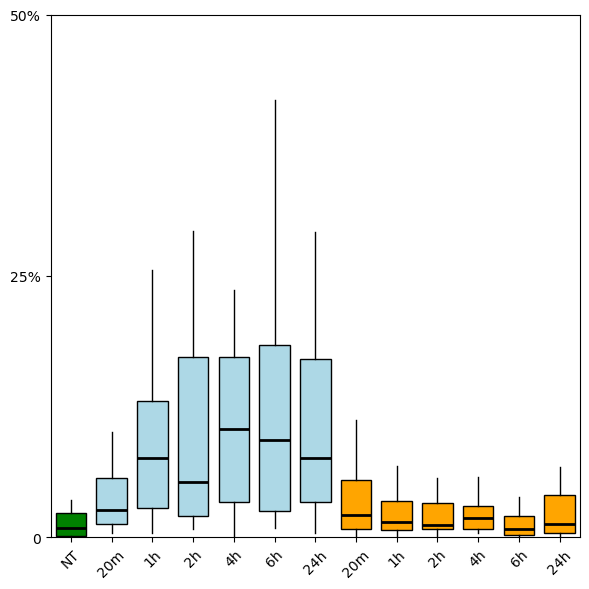

In [3]:
# Plot boxplot of percent of nuclei above threshold per image for HU cells by treat time and treat mode (robust version)
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
HU_df = per_nuclei_df[(per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['TreatMode'].isin(['DA', 'DR']))]
treat_times = HU_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times])
data = []
labels = []
for dr in ['DA', 'DR']:
    for t in treat_times:
        temp_df = HU_df[(HU_df['Treat Time'] == str(t)) & (HU_df['TreatMode'] == dr)]
        counts_all = temp_df['ImageNumber'].value_counts().sort_index()
        temp_df_thr = temp_df[temp_df['Nuclei_Intensity_MeanIntensity_NOTCH'] < 0.125] # Thresholds NCH <0.125, HES <0.385
        counts = temp_df_thr['ImageNumber'].value_counts().sort_index()
        percents = counts.reindex(counts_all.index, fill_value=0) / counts_all * 100
        # Only add if there are any images for this group
        if len(percents) > 0:
            arr = percents.values
            if arr.size > 0:
                data.append(arr)
                labels.append(f'{t}h-{dr}')
            # Optionally print for debugging
            # print(f'{t}h-{dr}: {arr}')
        # else:
        #     print(f'Skipped {t}h-{dr} (no data)')

# Final check: remove any empty arrays (should not be needed, but for safety)
data = [arr for arr in data if arr.size > 0]
labels = [labels[i] for i in range(len(data))]
# Order labels
# DA first [NT],0.5,1,2,4,6,24 then DR [0.5,1,2,4,6,24]
order = ['NT', '0.5', '1', '2', '4', '6', '24']
ordered_labels = []
ordered_data = []

for dr in ['DA', 'DR']:
    for t in order:
        label = f'{t}h-{dr}'
        if label in labels:
            idx = labels.index(label)
            ordered_labels.append(label)
            ordered_data.append(data[idx])
labels = ordered_labels
data = ordered_data

plt.figure(figsize=(6, 6))

# Colour boxplots according to colours list
box = plt.boxplot(data,
            positions=np.arange(1, len(labels) + 1),
            patch_artist=True,
            widths=0.75,
            whiskerprops=dict(linewidth=1),
            showmeans=False,
            showfliers=False,
            showcaps=False,
            medianprops=dict(color='black', linewidth=2),  # Hide medians
            # meanprops=dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=5)
            )
# plt.scatter(x=np.repeat(np.arange(1, len(labels) + 1), [len(arr) for arr in data]),
#             y=np.concatenate(data),
#             color='black', alpha=0.2, s=5)
colours = ['green', 'lightblue','lightblue','lightblue','lightblue','lightblue','lightblue','orange','orange','orange','orange','orange','orange']
for patch, color in zip(box['boxes'], colours):
    patch.set_facecolor(color)

plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=45)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13], labels=['NT','20m','1h','2h','4h','6h','24h','20m','1h','2h','4h','6h','24h'])
plt.yticks([0, 25, 50],labels=['0', '25%', '50%'])
# plt.xlabel('Treat Time and Treat Mode')
plt.ylim(0, 50)
# plt.ylabel('Percent of nuclei above threshold per image')
plt.tight_layout()
plt.show()


In [ ]:
# --- NICD/NOTCH relaxation fitting with explicit readout direction (DA=clearance, DR=recovery) ---
# This cell makes it obvious that:
#   DAPT addition (DA): NICD production stops -> underlying signal decays (clearance kinetics)
#   DAPT removal (DR): NICD production resumes -> underlying signal recovers (recovery kinetics)
#
# IMPORTANT: your current metric uses (intensity < threshold) for NOTCH, which is "LOW signal"
# Therefore, %LOW rises when the underlying signal decays, and %LOW falls when signal recovers.
# We handle this by optionally transforming %LOW -> %HIGH = 100 - %LOW before fitting kinetics.

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# USER SETTINGS
# -----------------------------
threshold = 0.125
intensity_col = 'Nuclei_Intensity_MeanIntensity_NOTCH'

# Choose metric explicitly:
#   metric_mode = "low"  -> % nuclei with LOW signal (e.g., intensity < threshold)
#   metric_mode = "high" -> % nuclei with HIGH signal (100-%low)
metric_mode = "low"   # set to "high" if you want direct, intuitive kinetics without inversion

# For NOTCH (as you currently do): low signal = intensity < threshold
# For HES (often): high signal = intensity > threshold
# We'll keep a generic predicate below.
assay = "NOTCH"  # "NOTCH" or "HES" (controls default predicate)

# Time labels
da_times_labels = ['NT', '0.5', '1', '2', '4', '6', '24']  # DAPT addition series
dr_times_labels = ['0.5', '1', '2', '4', '6', '24']        # DAPT removal series (we will inject 24h-DA as t=0)

time_map = {'NT': 0, '0.5': 20, '1': 60, '2': 120, '4': 240, '6': 360, '24': 1440}
da_times_min = np.array([time_map[t] for t in da_times_labels], dtype=float)
dr_times_min = np.array([0] + [time_map[t] for t in dr_times_labels], dtype=float)  # 0 = at washout start

# Fit window for DR (recovery) to avoid long-time noise (adjust if needed)
dr_fit_max_min = 1440  # fit recovery kinetics on 0..6h by default

# -----------------------------
# Helper: compute per-image percent of nuclei satisfying a predicate
# -----------------------------
def percent_by_predicate(df, treat_mode, treat_times, intensity_col, predicate_fn):
    """
    Returns arrays: mean and std across images, for each treat time label.
    """
    means, stds = [], []
    for t in treat_times:
        temp = df[(df['TreatMode'] == treat_mode) & (df['Treat Time'] == t)]
        if len(temp) == 0:
            means.append(np.nan); stds.append(np.nan); continue

        percs = []
        for _, group in temp.groupby('ImageNumber'):
            n = len(group)
            if n == 0:
                percs.append(np.nan); continue
            hits = predicate_fn(group[intensity_col]).sum()
            percs.append(100.0 * hits / n)

        means.append(np.nanmean(percs) if len(percs) else np.nan)
        stds.append(np.nanstd(percs) if len(percs) else np.nan)

    return np.array(means, float), np.array(stds, float)

# Predicate definition
if assay.upper() == "NOTCH":
    # your existing logic: "low" = intensity < threshold
    low_pred = lambda x: (x < threshold)
elif assay.upper() == "HES":
    # common alternative: "high" = intensity > threshold, so "low" = not high
    low_pred = lambda x: (x <= threshold)
else:
    raise ValueError("assay must be 'NOTCH' or 'HES'")

# -----------------------------
# Models (on the quantity we FIT)
# -----------------------------
def rise_model(t, y0, A, k):
    return y0 + (A - y0) * (1.0 - np.exp(-k * t))

def decay_model(t, y0, A0, k):
    return y0 + (A0 - y0) * np.exp(-k * t)

# -----------------------------
# Fit utilities
# -----------------------------
def _safe_curve_fit(model, t, y, p0, bounds=(-np.inf, np.inf), sigma=None):
    try:
        popt, pcov = curve_fit(model, t, y, p0=p0, bounds=bounds, sigma=sigma,
                               absolute_sigma=False, maxfev=20000)
        return popt, pcov
    except Exception as e:
        print("Fit error:", repr(e))
        return None, None

def summarize_rate(k_per_hour):
    if not np.isfinite(k_per_hour) or k_per_hour <= 0:
        return dict(tau_h=np.nan, tau_min=np.nan, t12_h=np.nan, t12_min=np.nan)
    tau_h = 1.0 / k_per_hour
    t12_h = np.log(2.0) / k_per_hour
    return dict(tau_h=tau_h, tau_min=60*tau_h, t12_h=t12_h, t12_min=60*t12_h)

def compute_fit_stats(y_true, y_pred, n_params):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]; y_pred = y_pred[mask]
    if len(y_true) == 0:
        return dict(SSE=np.nan, R2=np.nan, RMSE=np.nan, AIC=np.nan)

    resid = y_true - y_pred
    sse = float(np.sum(resid**2))
    rmse = float(np.sqrt(np.mean(resid**2)))
    ss_tot = float(np.sum((y_true - np.mean(y_true))**2))
    r2 = 1.0 - (sse / ss_tot) if ss_tot > 0 else np.nan
    n = len(y_true)
    aic = n * np.log(sse / n) + 2 * n_params if (sse > 0 and n > 0) else np.nan
    return dict(SSE=sse, R2=r2, RMSE=rmse, AIC=aic)

def sanitize_sigma(sig, mask, eps=1e-6):
    sig2 = sig.copy()
    med = np.nanmedian(sig2[mask]) if np.any(mask) else np.nan
    sig2[~np.isfinite(sig2)] = med
    sig2[sig2 < eps] = med if np.isfinite(med) else 1.0
    return sig2

def print_block(title, popt, pcov, names, k_index=2):
    print("\n" + "="*88)
    print(title)
    print("="*88)
    if popt is None:
        print("No fit."); return
    if pcov is not None and np.all(np.isfinite(pcov)):
        perr = np.sqrt(np.diag(pcov))
    else:
        perr = np.full_like(popt, np.nan, dtype=float)
    for n, v, e in zip(names, popt, perr):
        print(f"{n:>8s} = {v:10.4f}  ± {e:10.4f}")
    k = popt[k_index]
    s = summarize_rate(k)
    print("\nDerived time scales:")
    print(f"  k     = {k:.4f}  1/h")
    print(f"  tau   = {s['tau_h']:.4f} h  ({s['tau_min']:.1f} min)")
    print(f"  t1/2  = {s['t12_h']:.4f} h  ({s['t12_min']:.1f} min)")

def annotate_text_from_fit(popt, label_extra=""):
    if popt is None:
        return "fit failed"
    k = popt[2]
    s = summarize_rate(k)
    return f"k={k:.3f} 1/h\n" \
           f"t1/2={s['t12_min']:.1f} min\n" \
           f"tau={s['tau_min']:.1f} min\n" + label_extra

# -----------------------------
# 1) Extract the RAW readout (%LOW by default predicate)
# -----------------------------
da_low_mean, da_low_std = percent_by_predicate(HU_df, 'DA', da_times_labels, intensity_col, low_pred)
dr_low_mean, dr_low_std = percent_by_predicate(HU_df, 'DR', dr_times_labels, intensity_col, low_pred)

# DR needs the t=0 point = the 24h DA endpoint (maximal inhibition baseline)
da24_low_mean = da_low_mean[-1]
da24_low_std  = da_low_std[-1]
dr_low_mean = np.insert(dr_low_mean, 0, da24_low_mean)
dr_low_std  = np.insert(dr_low_std,  0, da24_low_std)

# -----------------------------
# 2) Convert to the quantity we want to INTERPRET as "signal"
# -----------------------------
# If metric_mode="low", then low% is anti-correlated with underlying NOTCH/NICD nuclear signal.
# If we want to fit "signal decay" and "signal recovery" kinetics, we should fit HIGH% = 100 - LOW%.
if metric_mode.lower() == "low":
    da_signal_mean = 100.0 - da_low_mean
    da_signal_std  = da_low_std          # std unchanged under linear transform
    dr_signal_mean = 100.0 - dr_low_mean
    dr_signal_std  = dr_low_std
    readout_name = "% HIGH signal (computed as 100 - %LOW)"
else:
    # If you already computed a "high" metric upstream, you would directly use it here.
    # For convenience, still transform from low since we computed low above:
    da_signal_mean = 100.0 - da_low_mean
    da_signal_std  = da_low_std
    dr_signal_mean = 100.0 - dr_low_mean
    dr_signal_std  = dr_low_std
    readout_name = "% HIGH signal (direct)"

# -----------------------------
# 3) Fit the BIOLOGICAL kinetics
#     DA = clearance/decay of signal
#     DR = recovery/rise of signal
# -----------------------------
# Valid masks + weights
da_valid = np.isfinite(da_times_min) & np.isfinite(da_signal_mean)
dr_valid = np.isfinite(dr_times_min) & np.isfinite(dr_signal_mean)

da_sigma = sanitize_sigma(np.where(np.isfinite(da_signal_std), da_signal_std, np.nan), da_valid)
dr_sigma = sanitize_sigma(np.where(np.isfinite(dr_signal_std), dr_signal_std, np.nan), dr_valid)

# DA clearance: fit DECAY to baseline
# y0 ~ late time, A0 ~ early time
p0_da = (da_signal_mean[da_valid][-1], da_signal_mean[da_valid][0], 0.8)
bounds = ([-np.inf, -np.inf, 1e-6], [np.inf, np.inf, 1e3])

popt_da, pcov_da = _safe_curve_fit(
    decay_model,
    da_times_h[da_valid],
    da_signal_mean[da_valid],
    p0=p0_da,
    bounds=bounds,
    sigma=da_sigma[da_valid]
)

# DR recovery: fit RISE to asymptote
# y0 ~ start (max inhibited), A ~ late (recovered)
dr_early_mask = dr_valid & (dr_times_min <= dr_fit_max_min)
use_mask = dr_early_mask if np.sum(dr_early_mask) >= 3 else dr_valid

p0_dr = (dr_signal_mean[use_mask][0], dr_signal_mean[use_mask][-1], 0.8)

popt_dr, pcov_dr = _safe_curve_fit(
    rise_model,
    dr_times_min[use_mask],
    dr_signal_mean[use_mask],
    p0=p0_dr,
    bounds=bounds,
    sigma=dr_sigma[use_mask]
)

# -----------------------------
# 4) Print results with explicit meaning
# -----------------------------
print_block(
    "DA (DAPT addition) — SIGNAL CLEARANCE (decay) fit  [NICD production blocked]",
    popt_da, pcov_da, names=["baseline(y0)", "start(A0)", "k_clear"]
)

fit_window = f"0–{dr_fit_max_h:.0f}h" if np.all(dr_times_h[use_mask] <= dr_fit_max_h) else "all points"
print_block(
    f"DR (DAPT removal) — SIGNAL RECOVERY (rise) fit  [NICD production resumes]  (fit window: {fit_window})",
    popt_dr, pcov_dr, names=["start(y0)", "asymptote(A)", "k_recov"]
)

# Reviewer-facing derived metrics at 20 min and 1 h
t20 = 20.0/60.0
print("\n" + "-"*88)
print("Reviewer-facing derived metrics (on interpreted HIGH-signal readout)")
print("-"*88)

if popt_da is not None:
    pred20 = decay_model(t20, *popt_da)
    pred60 = decay_model(1.0, *popt_da)
    print(f"DA clearance: predicted signal at 20 min = {pred20:.2f}; at 1 h = {pred60:.2f}")
if popt_dr is not None:
    pred20 = rise_model(t20, *popt_dr)
    pred60 = rise_model(1.0, *popt_dr)
    print(f"DR recovery:  predicted signal at 20 min = {pred20:.2f}; at 1 h = {pred60:.2f}")

# Fit stats
if popt_da is not None:
    da_pred = decay_model(da_times_h[da_valid], *popt_da)
    da_stats = compute_fit_stats(da_signal_mean[da_valid], da_pred, n_params=3)
    print("\nDA clearance fit stats:")
    for k, v in da_stats.items():
        print(f"  {k:>4s}: {v:.4f}")

if popt_dr is not None:
    dr_pred = rise_model(dr_times_h[use_mask], *popt_dr)
    dr_stats = compute_fit_stats(dr_signal_mean[use_mask], dr_pred, n_params=3)
    print(f"\nDR recovery fit stats (window {fit_window}):")
    for k, v in dr_stats.items():
        print(f"  {k:>4s}: {v:.4f}")

# -----------------------------
# 5) Plots: show BOTH the raw metric (%LOW) and the interpreted HIGH-signal used for fitting
# -----------------------------
def plot_with_fit(times, mean_raw, std_raw, mean_sig, std_sig, model, popt, title, xlabel, fit_mask=None):
    plt.figure(figsize=(8, 5))
    # Raw
    plt.errorbar(times, mean_raw, yerr=std_raw, fmt='o', alpha=0.75, label="raw: %LOW (intensity<thr)")
    # Interpreted signal
    plt.errorbar(times, mean_sig, yerr=std_sig, fmt='o', alpha=0.9, label=f"interpreted signal: {readout_name}")

    if popt is not None:
        tgrid = np.linspace(np.nanmin(times), np.nanmax(times), 250)
        plt.plot(tgrid, model(tgrid, *popt), lw=2, label="fit (on interpreted signal)")
    if fit_mask is not None:
        plt.scatter(times[fit_mask], mean_sig[fit_mask], s=80, facecolors='none', edgecolors='k', label="points used for fit")

    plt.xlabel(xlabel)
    plt.ylabel("% nuclei")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if popt is not None:
        plt.gca().text(0.02, 0.98, annotate_text_from_fit(popt), transform=plt.gca().transAxes,
                       va='top', ha='left', fontsize=10, bbox=dict(boxstyle='round', alpha=0.15))
    plt.show()

# DA plot (clearance)
plot_with_fit(
    da_times_h,
    da_low_mean, da_low_std,
    da_signal_mean, da_signal_std,
    decay_model, popt_da,
    title="DA (DAPT addition): underlying SIGNAL CLEARANCE (production blocked)",
    xlabel="Time since DAPT addition (h)",
    fit_mask=da_valid
)

# DR plot (recovery)
plot_with_fit(
    dr_times_h,
    dr_low_mean, dr_low_std,
    dr_signal_mean, dr_signal_std,
    rise_model, popt_dr,
    title="DR (DAPT removal): underlying SIGNAL RECOVERY (production resumes)",
    xlabel="Time since DAPT removal (h)",
    fit_mask=use_mask
)


In [ ]:
# --- KRUSKAL-WALLIS TEST AND POST HOC (DUNN'S TEST) ---
from scipy.stats import kruskal
import scikit_posthocs as sp

# Kruskal-Wallis test across all groups
groups_kw = [arr for arr in data]
kruskal_result = kruskal(*groups_kw)
print(f'Kruskal-Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.4g}')

# Prepare data for post hoc Dunn's test
all_percents = np.concatenate(data)
group_labels = np.concatenate([[label]*len(arr) for label, arr in zip(labels, data)])

# Dunn's test (pairwise comparisons, Bonferroni correction)
if "sp" in globals():
    import pandas as pd
    df_posthoc = pd.DataFrame({'percent': all_percents, 'group': group_labels})
    dunn_result = sp.posthoc_dunn(df_posthoc, val_col='percent', group_col='group', p_adjust='bonferroni')
    print('Dunn post hoc pairwise p-values:')
    print(dunn_result)
else:
    print('Dunn post hoc test not run (scikit-posthocs missing).')


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
0.5h-DA  1h-DA  -0.0079 0.0004 -0.0134 -0.0025   True
0.5h-DA 24h-DA  -0.0068 0.0053 -0.0124 -0.0013   True
0.5h-DA  2h-DA  -0.0166    0.0 -0.0221 -0.0112   True
0.5h-DA  4h-DA  -0.0294    0.0 -0.0349 -0.0239   True
0.5h-DA  6h-DA   -0.022    0.0 -0.0275 -0.0165   True
0.5h-DA NTh-DA   0.0369    0.0  0.0313  0.0425   True
  1h-DA 24h-DA   0.0011 0.9975 -0.0044  0.0066  False
  1h-DA  2h-DA  -0.0087    0.0 -0.0142 -0.0033   True
  1h-DA  4h-DA  -0.0214    0.0 -0.0269  -0.016   True
  1h-DA  6h-DA  -0.0141    0.0 -0.0195 -0.0086   True
  1h-DA NTh-DA   0.0448    0.0  0.0393  0.0504   True
 24h-DA  2h-DA  -0.0098    0.0 -0.0153 -0.0043   True
 24h-DA  4h-DA  -0.0225    0.0 -0.0281  -0.017   True
 24h-DA  6h-DA  -0.0151    0.0 -0.0207 -0.0096   True
 24h-DA NTh-DA   0.0438    0.0  0.0381  0.0494   True
  2h-DA  4h-DA  -0.0127    0

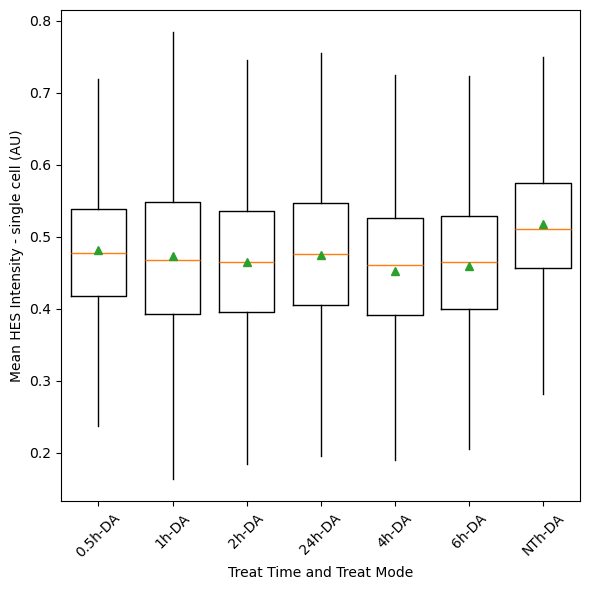

In [10]:
# Plot the individual Nuclei_Intensity_MeanIntensity_HES values for HU_cells grouped by treat time and treat mode
import matplotlib.pyplot as plt
import numpy as np
HU_df = per_nuclei_df[(per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['TreatMode'].isin(['DA', 'DR']))]
HU_df = HU_df[HU_df['Treat Time'].isin(['NT','0.5','1', '2', '4','5' ,'6','24'])]
treat_times = sorted([str(t) for t in HU_df['Treat Time'].unique()])
data = []
labels = []

for dr in ['DA']:
    for t in treat_times: 
        temp_df = HU_df[(HU_df['Treat Time'] == str(t)) & (HU_df['TreatMode'] == dr)]
        temp_df = temp_df[temp_df['Nuclei_Intensity_MeanIntensity_HES'] <0.8]
        hes_values = temp_df['Nuclei_Intensity_MeanIntensity_HES'].values
        data.append(hes_values)
        labels.append(f'{t}h-{dr}')

# Flatten data and create group labels
all_values = np.concatenate(data)
group_labels = np.concatenate([[label]*len(arr) for label, arr in zip(labels, data)])

# Run Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=all_values, groups=group_labels, alpha=0.05)
print(tukey)


plt.figure(figsize=(6, 6))
plt.boxplot(data, 
            positions=np.arange(1, len(labels) + 1), 
            widths=0.75, 
            showmeans=True, 
            showfliers=False,
            showcaps=False)
plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=45)
plt.xlabel('Treat Time and Treat Mode')
plt.ylabel('Mean HES Intensity - single cell (AU)')
# plt.title('Violin Plot of Individual HES Values by Treat Time and Treat Mode for HU Cells')
plt.tight_layout()
plt.show()

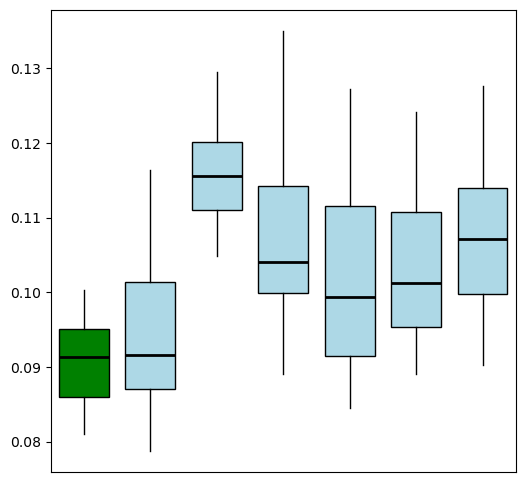

Kruskal-Wallis H = 85.278, p = 2.891e-16
Dunn post hoc pairwise p-values:
              0.5h-DA         1h-DA    24h-DA         2h-DA     4h-DA  \
0.5h-DA  1.000000e+00  1.698465e-09  0.001465  8.904605e-04  0.383402   
1h-DA    1.698465e-09  1.000000e+00  0.245171  3.396451e-01  0.000734   
24h-DA   1.464783e-03  2.451707e-01  1.000000  1.000000e+00  1.000000   
2h-DA    8.904605e-04  3.396451e-01  1.000000  1.000000e+00  1.000000   
4h-DA    3.834017e-01  7.338178e-04  1.000000  1.000000e+00  1.000000   
6h-DA    1.017537e-01  4.863051e-03  1.000000  1.000000e+00  1.000000   
NTh-DA   1.000000e+00  3.784211e-14  0.000001  6.023528e-07  0.002852   

            6h-DA        NTh-DA  
0.5h-DA  0.101754  1.000000e+00  
1h-DA    0.004863  3.784211e-14  
24h-DA   1.000000  1.167369e-06  
2h-DA    1.000000  6.023528e-07  
4h-DA    1.000000  2.852128e-03  
6h-DA    1.000000  4.060218e-04  
NTh-DA   0.000406  1.000000e+00  


In [17]:
# Plot the standard deviations of Nuclei_Intensity_MeanIntensity_HESvalues by image grouped by treat time and treat mode
import matplotlib.pyplot as plt
import numpy as np
HU_df = per_nuclei_df[(per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['TreatMode'].isin(['DA', 'DR']))]
HU_df = HU_df[HU_df['Treat Time'].isin(['NT','0.5','1', '2', '4','6' ,'24'])]
treat_times = HU_df['Treat Time'].unique()
# treat_times = sorted([str(t) for t in treat_times])
data = []
labels = []
for dr in ['DA']:
    for t in treat_times: 
         temp_df = HU_df[(HU_df['Treat Time'] == str(t)) & (HU_df['TreatMode'] == dr)]
         stds = temp_df.groupby('ImageNumber')['Nuclei_Intensity_MeanIntensity_HES'].std().dropna().values
         data.append(stds)
         labels.append(f'{t}h-{dr}')

plt.figure(figsize=(6, 6))
box = plt.boxplot(data, 
            positions=np.arange(1, len(labels) + 1),
            patch_artist=True,
            orientation='vertical', 
            widths=0.75, 
            showmeans=False, 
            showfliers=False,
            showcaps=False,
            medianprops=dict(color='black', linewidth=2))
colours = ['green', 'lightblue','lightblue','lightblue','lightblue','lightblue','lightblue']
for patch, color in zip(box['boxes'], colours):
    patch.set_facecolor(color)

# plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=45)
plt.xticks([])
# plt.xlabel('Treat Time and Treat Mode')
# plt.ylabel('Standard Deviation of Nuclei Intensity Mean Intensity HES per Image')
# plt.title('Boxplot of Standard Deviations of HES Values by Treat Time and Treat Mode for HU Cells')
plt.show()

# perform Kruskal-Wallis + post hoc Dunn's test on std data
from scipy.stats import kruskal
import scikit_posthocs as sp
# Kruskal-Wallis test across all groups
groups_kw = [arr for arr in data]
kruskal_result = kruskal(*groups_kw)
print(f'Kruskal-Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.4g}')
# Prepare data for post hoc Dunn's test
all_stds = np.concatenate(data)
group_labels = np.concatenate([[label]*len(arr) for label, arr in zip(labels, data)])
# Dunn's test (pairwise comparisons, Bonferroni correction)
df_posthoc = pd.DataFrame({'std': all_stds, 'group': group_labels})
dunn_result = sp.posthoc_dunn(df_posthoc, val_col='std', group_col='group', p_adjust='bonferroni')
print('Dunn post hoc pairwise p-values:')
print(dunn_result)


In [59]:
# Select NT HES1 intensity values
nt_hes = per_nuclei_df[(per_nuclei_df['Treat Time'] == 'NT') & (per_nuclei_df['CellType'] == 'HU')]['Nuclei_Intensity_MeanIntensity_HES'].dropna()

# Sigma-based thresholds
mean = nt_hes.mean()
std = nt_hes.std()
low_sigma = mean - 2 * std
high_sigma = mean + 2 * std

# Percentile-based thresholds (10% low/high)
low_percentile = np.percentile(nt_hes, 5) # 5th percentile
high_percentile = np.percentile(nt_hes, 95) # 95th percentile

print(f"Mean: {mean:.4f}, Std: {std:.4f}")
print(f"Sigma-based: Low < {low_sigma:.4f}, High > {high_sigma:.4f}")
print(f"Percentile-based: Low < {low_percentile:.4f} (5th), High > {high_percentile:.4f} (95th)")

Mean: 0.5195, Std: 0.0924
Sigma-based: Low < 0.3347, High > 0.7044
Percentile-based: Low < 0.3813 (5th), High > 0.6847 (95th)


Mean NOTCH for 4: 0.4535
Dataset 4 length: 6981
Mean NOTCH for 6: 0.4607
Dataset 6 length: 7005
Mean NOTCH for NT: 0.5195
Dataset NT length: 6431


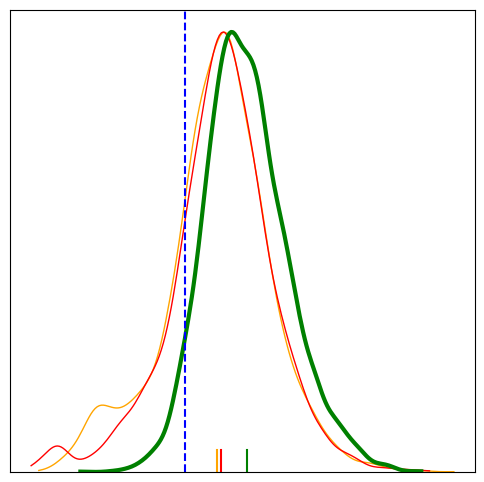

In [4]:
# Plot the density distributions of HES values by image grouped by treat time and treat mode
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
HU_df = per_nuclei_df[(per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['TreatMode'].isin(['DA', 'DR']))]
HU_df = HU_df[HU_df['Treat Time'].isin(['NT', '4', '6'])]

nt_hes = HU_df[HU_df['Treat Time'] == 'NT']['Nuclei_Intensity_MeanIntensity_HES'].values
low_percentile = np.percentile(nt_hes, 5) # 5th percentile

treat_times = HU_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times]) 
data = []
labels = []
for tr_m in ['DA']:
    for t in treat_times: 
         temp_df = HU_df[(HU_df['Treat Time'] == str(t)) & (HU_df['TreatMode'] == tr_m)]
         hes_values = temp_df['Nuclei_Intensity_MeanIntensity_HES'].values
         data.append(hes_values)
         labels.append(f'{t}')
plt.figure(figsize=(6, 6))
# Colourscale brg for treat times
colours = ['orange', 'red', 'green']
for i, hes_values in enumerate(data):
    density = stats.gaussian_kde(hes_values)
    mean_hes = np.mean(hes_values)
    print(f'Mean NOTCH for {labels[i]}: {mean_hes:.4f}')
    xs = np.linspace(min(hes_values), max(hes_values), 200)
    # plt.plot(xs, density(xs), label=labels[i], color=plt.cm.gist_heat(i / len(data)))
    # Print dataset length
    print(f'Dataset {labels[i]} length: {len(hes_values)}')
    ys = density(xs)
    ys_scaled = ys / ys.max()  # Scale to 0-1
    line_tick = 3 if labels[i] == 'NT' else 1
    plt.plot(xs, ys_scaled, label=labels[i], color=colours[i], linewidth=line_tick)
    # Annotate mean with a short (y = 0.1) vertical segment on x axis
    plt.plot([mean_hes, mean_hes], [0, 0.05], color=colours[i], linewidth=1.5)



# Plot a vertical line at low_percentile
plt.axvline(x=low_percentile, color='blue', linestyle='--', label='5th Percentile NT')
plt.xticks([])
plt.yticks([])
# plt.xlabel('Nuclei Intensity Mean Intensity HES')
# plt.ylabel('Density')
# plt.xlim(0, 0.7)
plt.ylim(0, 1.05)
# plt.title('Density Distributions of HES Values by Treat Time and Treat Mode for HU Cells')
# plt.legend()
plt.show()

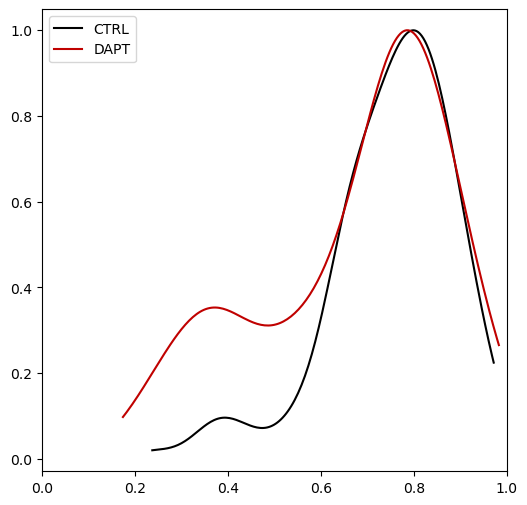

In [152]:
# Plot the HES KDE distribution by treat time 
import matplotlib.pyplot as plt
import numpy as np
HU_df = per_nuclei_Sparse_df[(per_nuclei_Sparse_df['CellType'] == 'HUVEC')]
HU_df = HU_df[HU_df['Treat Time'].isin(['CTRL','DAPT'])]
# Drop images with more than 8 entries
image_counts = HU_df['ImageNumber'].value_counts()
images_to_keep = image_counts[image_counts <= 10].index
HU_df = HU_df[HU_df['ImageNumber'].isin(images_to_keep)]
# HU_df = HU_df[HU_df['Nuclei_Intensity_MeanIntensity_HES'] > 0.2]
HU_df = HU_df[HU_df['Nuclei_Neighbors_PercentTouching_20'] < 1]
HU_df = HU_df[(HU_df['Nuclei_AreaShape_Area'] > 2000) & (HU_df['Nuclei_AreaShape_Area'] < 2800)]

treat_times = HU_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times])
data = []
labels = []
for t in treat_times: 
     temp_df = HU_df[(HU_df['Treat Time'] == str(t))]
     hes_values = temp_df['Nuclei_Intensity_MeanIntensity_NOTCH'].values
     data.append(hes_values)
     labels.append(f'{t}')
plt.figure(figsize=(6, 6))
# Colourscale brg for treat times
for i, hes_values in enumerate(data):
    density = stats.gaussian_kde(hes_values)
    xs = np.linspace(min(hes_values), max(hes_values), 200)
    # plt.plot(xs, density(xs), label=labels[i], color=plt.cm.gist_heat(i / len(data)))
    ys = density(xs)
    ys_scaled = ys / ys.max()  # Scale to 0-1
    plt.plot(xs, ys_scaled, label=labels[i], color=plt.cm.gist_heat(i / len(data)))
# plt.xticks([])
# plt.yticks([])
# plt.xlabel('Nuclei Intensity Mean Intensity HES')
# plt.ylabel('Density')
plt.xlim(0, 1.0)
# plt.title('Density Distributions of HES Values by Treat Time for HU Cells')
plt.legend()
plt.show()

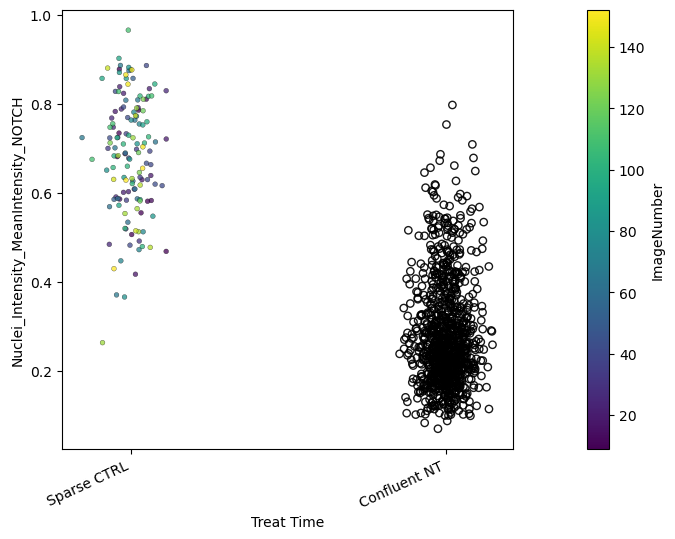

In [123]:
# Plot HES intensity mean values in CTRL sparse and confluent cells
import matplotlib.pyplot as plt
import numpy as np

# Filter sparse HUVEC CTRL cells
HU_df = per_nuclei_Sparse_df[(per_nuclei_Sparse_df['CellType'] == 'HUVEC')]
HU_df = HU_df[HU_df['Treat Time'].isin(['CTRL'])]
# Drop images with more than 5 entries
image_counts = HU_df['ImageNumber'].value_counts()
images_to_keep = image_counts[image_counts <= 10].index
HU_df = HU_df[HU_df['ImageNumber'].isin(images_to_keep)]

# Drop cells with Nuclei_Neighbors_PercentTouching_20 > 5
HU_df = HU_df[HU_df['Nuclei_Neighbors_PercentTouching_20'] < 1]
# Drop cells with Nuclei_Intensity_MeanIntensity_HES < 0.6
# HU_df = HU_df[HU_df['Nuclei_Intensity_MeanIntensity_HES'] > 0.59]
HU_df = HU_df[(HU_df['Nuclei_AreaShape_Area'] > 2000) & (HU_df['Nuclei_AreaShape_Area'] < 2800)]


# Prepare color normalization for sparse points
img_numbers = HU_df['ImageNumber'].values
norm = plt.Normalize(vmin=img_numbers.min(), vmax=img_numbers.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(7, 5.5))

# Plot sparse HUVEC CTRL points at x=1 with jitter
temp_df = HU_df[HU_df['Treat Time'] == 'CTRL']
hes_values = temp_df['Nuclei_Intensity_MeanIntensity_HES'].values
jittered_x_sparse = np.random.normal(loc=1, scale=0.05, size=len(hes_values))
ax.scatter(
    jittered_x_sparse, hes_values,
    c=temp_df['ImageNumber'].values, cmap=cmap, norm=norm,
    alpha=0.75, edgecolors='k', linewidths=0.25, s=12,
    label='Sparse CTRL', zorder=2
)

# Plot confluent HUVEC NT points at x=2 with jitter
confluent_df = per_nuclei_df[
    (per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['Treat Time'] == 'NT')
]
# Filter by area shape to match sparse
confluent_df = confluent_df[
    (confluent_df['Nuclei_AreaShape_Area'] > 2000) & (confluent_df['Nuclei_AreaShape_Area'] < 2800)
]

confluent_hes = confluent_df['Nuclei_Intensity_MeanIntensity_NOTCH'].values

jittered_x_confluent = np.random.normal(loc=2, scale=0.05, size=len(confluent_hes))
ax.scatter(
    jittered_x_confluent, confluent_hes,
    facecolor='none', edgecolor='black', marker='o', s=28,
    alpha=0.9, label='Confluent NT', zorder=4
)

# Axes/labels
ax.set_xticks([1, 2])
ax.set_xticklabels(['Sparse CTRL', 'Confluent NT'], rotation=25, ha='right')
ax.set_xlabel('Treat Time')
ax.set_ylabel('Nuclei_Intensity_MeanIntensity_NOTCH')

# Colorbar for sparse points
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='ImageNumber', pad=0.12)

fig.tight_layout()
plt.show()


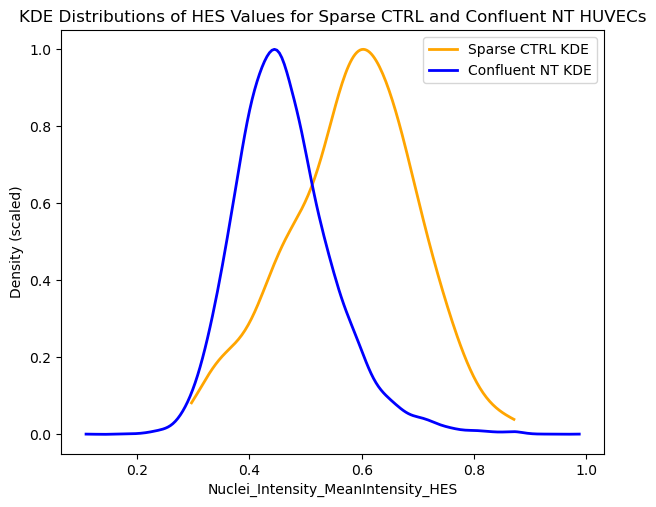

In [120]:
# Plot the HES KDE distributions for sparse and confluent HUVEC NT cells after filtering
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats 
# Filter sparse HUVEC NT cells
HU_df = per_nuclei_Sparse_df[(per_nuclei_Sparse_df['CellType'] == 'HUVEC')]
HU_df = HU_df[HU_df['Treat Time'].isin(['CTRL'])]
# Drop images with more than 5 entries
image_counts = HU_df['ImageNumber'].value_counts()
images_to_keep = image_counts[image_counts <= 10].index
HU_df = HU_df[HU_df['ImageNumber'].isin(images_to_keep)]

# Drop cells with Nuclei_Neighbors_PercentTouching_20 > 5
HU_df = HU_df[HU_df['Nuclei_Neighbors_PercentTouching_20'] < 1]
# Drop cells with Nuclei_Intensity_MeanIntensity_HES < 0.6
# HU_df = HU_df[HU_df['Nuclei_Intensity_MeanIntensity_HES'] > 0.32]
# HU_df = HU_df[(HU_df['Nuclei_AreaShape_Area'] > 2000) & (HU_df['Nuclei_AreaShape_Area'] < 2800)]
HU_df = HU_df[HU_df['Nuclei_Intensity_MeanIntensity_Nuclei'] > 0.6]

# Prepare color normalization for sparse points
img_numbers = HU_df['ImageNumber'].values
norm = plt.Normalize(vmin=img_numbers.min(), vmax=img_numbers.max())
cmap = plt.cm.Set1
fig, ax = plt.subplots(figsize=(7, 5.5))
# Plot sparse HUVEC NT KDE
temp_df = HU_df[HU_df['Treat Time'] == 'CTRL']
hes_values = temp_df['Nuclei_Intensity_MeanIntensity_HES'].values / temp_df['Nuclei_Intensity_MeanIntensity_Nuclei'].values * 0.6
density = stats.gaussian_kde(hes_values)
xs = np.linspace(min(hes_values), max(hes_values), 200) 
ys = density(xs)
ys_scaled = ys / ys.max()  # Scale to 0-1
ax.plot(xs, ys_scaled, label='Sparse CTRL KDE', color='orange', linewidth=2, zorder=3)
# Plot confluent HUVEC NT KDE
confluent_df = per_nuclei_df[
    (per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['Treat Time'] == 'NT')
]

confluent_hes = confluent_df['Nuclei_Intensity_MeanIntensity_HES'].values / confluent_df['Nuclei_Intensity_MeanIntensity_Nuclei'].values * 0.5
density_confluent = stats.gaussian_kde(confluent_hes)
xs_confluent = np.linspace(min(confluent_hes), max(confluent_hes), 200)
ys_confluent = density_confluent(xs_confluent)
ys_confluent_scaled = ys_confluent / ys_confluent.max()  # Scale to 0-1
ax.plot(xs_confluent, ys_confluent_scaled, label='Confluent NT KDE', color='blue', linewidth=2, zorder=4)
# Axes/labels
ax.set_xlabel('Nuclei_Intensity_MeanIntensity_HES')
ax.set_ylabel('Density (scaled)')
ax.set_title('KDE Distributions of HES Values for Sparse CTRL and Confluent NT HUVECs')
ax.legend()
plt.show()      

/Users/lory/miniconda_2/miniconda3/envs/ECConnect/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6431.
  res = hypotest_fun_out(*samples, **kwds)


Confluent Shapiro-Wilk p-value: 0.0000
Sparse Shapiro-Wilk p-value: 0.1062


/Users/lory/miniconda_2/miniconda3/envs/ECConnect/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6431.
  res = hypotest_fun_out(*samples, **kwds)


Confluent Shapiro-Wilk p-value: 0.0000
Sparse Shapiro-Wilk p-value: 0.1062


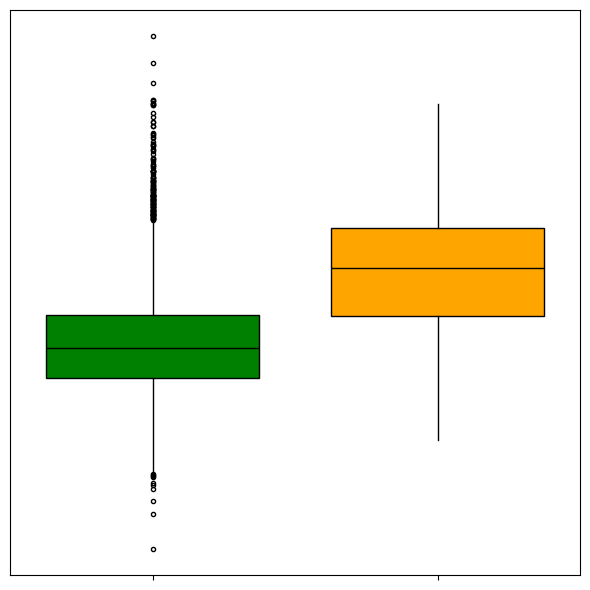

In [122]:
# PLot Boxplots of HES values for sparse and confluent HUVEC NT cells after filtering
import matplotlib.pyplot as plt
import numpy as np
# Filter sparse HUVEC NT cells
HU_df = per_nuclei_Sparse_df[(per_nuclei_Sparse_df['CellType'] == 'HUVEC')]
HU_df = HU_df[HU_df['Treat Time'] == 'CTRL']
# Drop images with more than 5 entries
image_counts = HU_df['ImageNumber'].value_counts()
images_to_keep = image_counts[image_counts <= 10].index
HU_df = HU_df[HU_df['ImageNumber'].isin(images_to_keep)]
# Drop cells with Nuclei_Neighbors_PercentTouching_20 > 5
HU_df = HU_df[HU_df['Nuclei_Neighbors_PercentTouching_20'] < 1]
# Drop cells with Nuclei_Intensity_MeanIntensity_HES < 0.6
# HU_df = HU_df[HU_df['Nuclei_Intensity_MeanIntensity_HES'] > 0.59]
# HU_df = HU_df[(HU_df['Nuclei_AreaShape_Area'] > 2000) & (HU_df['Nuclei_AreaShape_Area'] < 2800)]
HU_df = HU_df[HU_df['Nuclei_Intensity_MeanIntensity_Nuclei'] > 0.6]
# Prepare data for boxplot
sparse_hes = HU_df[HU_df['Treat Time'] == 'CTRL']['Nuclei_Intensity_MeanIntensity_HES'].values / HU_df[HU_df['Treat Time'] == 'CTRL']['Nuclei_Intensity_MeanIntensity_Nuclei'].values * 0.6
confluent_df = per_nuclei_df[
    (per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['Treat Time'] == 'NT')
]
confluent_hes = confluent_df['Nuclei_Intensity_MeanIntensity_HES'].values / confluent_df['Nuclei_Intensity_MeanIntensity_Nuclei'].values * 0.5

# Test normality of distribution around the respective means
from scipy.stats import shapiro

for arr, label in zip([confluent_hes, sparse_hes], ['Confluent', 'Sparse']):
    stat, p = shapiro(arr)
    print(f"{label} Shapiro-Wilk p-value: {p:.4f}")

data = [confluent_hes, sparse_hes]
labels = ['Confluent', 'Sparse']
plt.figure(figsize=(6, 6))
box = plt.boxplot(data, patch_artist=True, widths=0.75, showmeans=False, showfliers=True, showcaps=False, medianprops=dict(color='black', linewidth=1), flierprops=dict(marker='o', color='black', markersize=3))
colours = ['green', 'orange']
for patch, color in zip(box['boxes'], colours):
    patch.set_facecolor(color)
plt.xticks([1, 2], [])
plt.yticks([])
# plt.xlabel('Treat Time')
# plt.ylabel('Nuclei_Intensity_MeanIntensity_HES (%)')
# plt.title('Boxplot of HES Values for Confluent NT and Sparse CTRL HUVECs')
plt.tight_layout()
plt.show()

Number of sparse CTRL cells: 1081
Number of confluent NT cells: 6431
Confluent Shapiro-Wilk p-value: 0.0000
Sparse Shapiro-Wilk p-value: 0.0000


/Users/lory/miniconda_2/miniconda3/envs/ECConnect/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6431.
  res = hypotest_fun_out(*samples, **kwds)


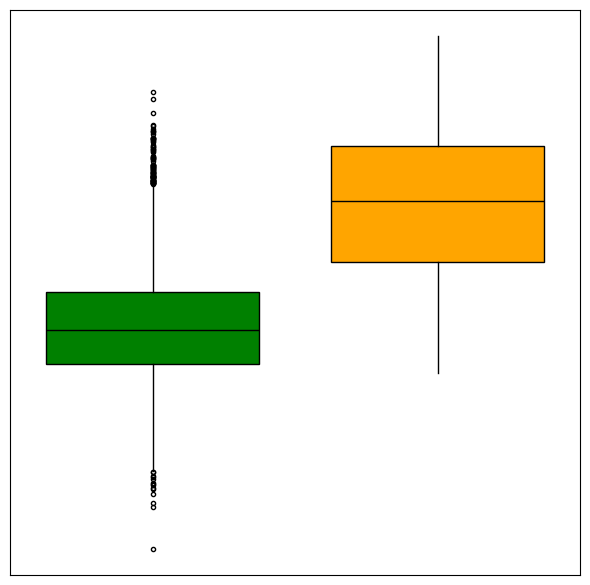

In [166]:
# PLot Boxplots of HES values for sparse and confluent HUVEC NT cells after filtering
import matplotlib.pyplot as plt
import numpy as np
# Filter sparse HUVEC NT cells
HU_df = per_nuclei_Sparse_df[(per_nuclei_Sparse_df['CellType'] == 'HUVEC')]
HU_df = HU_df[HU_df['Treat Time'] == 'CTRL']
# Drop images with more than 5 entries
image_counts = HU_df['ImageNumber'].value_counts()
images_to_keep = image_counts[image_counts <= 15].index
HU_df = HU_df[HU_df['ImageNumber'].isin(images_to_keep)]
# Drop cells with Nuclei_Neighbors_PercentTouching_20 > 5
# HU_df = HU_df[HU_df['Nuclei_Neighbors_PercentTouching_20'] < 1]
# Drop cells with Nuclei_Intensity_MeanIntensity_HES < 0.6
# HU_df = HU_df[HU_df['Nuclei_Intensity_MeanIntensity_HES'] > 0.59]
# HU_df = HU_df[(HU_df['Nuclei_AreaShape_Area'] > 2000) & (HU_df['Nuclei_AreaShape_Area'] < 2800)]
HU_df = HU_df[HU_df['Nuclei_Intensity_MeanIntensity_NOTCH'] > 0.44]
# Prepare data for boxplot
sparse_hes = HU_df[HU_df['Treat Time'] == 'CTRL']['Nuclei_Intensity_MeanIntensity_NOTCH'].values 

# Print number of sparse cells
print(f'Number of sparse CTRL cells: {len(sparse_hes)}')

confluent_df = per_nuclei_df[
    (per_nuclei_df['CellType'] == 'HU') & (per_nuclei_df['Treat Time'] == 'NT')
]
confluent_hes = confluent_df['Nuclei_Intensity_MeanIntensity_HES'].values
print(f'Number of confluent NT cells: {len(confluent_hes)}')
# Test normality of distribution around the respective means
from scipy.stats import shapiro

for arr, label in zip([confluent_hes, sparse_hes], ['Confluent', 'Sparse']):
    stat, p = shapiro(arr)
    print(f"{label} Shapiro-Wilk p-value: {p:.4f}")

data = [confluent_hes, sparse_hes]
labels = ['Confluent', 'Sparse']
plt.figure(figsize=(6, 6))

box = plt.boxplot(
    data,
    patch_artist=True,
    widths=0.75,
    showmeans=False,
    showfliers=True,
    showcaps=False,
    medianprops=dict(color='black', linewidth=1),
    boxprops=dict(color='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1),
    capprops=dict(color='black', linewidth=1),
    flierprops=dict(marker='o', color='black', markersize=3)
)
colours = ['green', 'orange']
for patch, color in zip(box['boxes'], colours):
    patch.set_facecolor(color)

plt.xticks([1, 2], [])
plt.yticks([])
# plt.xlabel('Treat Time')
# plt.ylabel('Nuclei_Intensity_MeanIntensity_HES (%)')
# plt.title('Boxplot of HES Values for Confluent NT and Sparse CTRL HUVECs')
plt.tight_layout()

# ax = plt.gca()
# ax.set_facecolor('none')
# plt.gcf().set_facecolor('none')

# # Set all spines, ticks, and labels to white
# for spine in ax.spines.values():
#     spine.set_color('none')
# ax.tick_params(colors='white')
# ax.yaxis.label.set_color('white')
# ax.xaxis.label.set_color('white')
# ax.title.set_color('white')

plt.xticks([])
plt.yticks([])
plt.show()

['0.7', '1', '2', '4', '5', '6', 'NT']


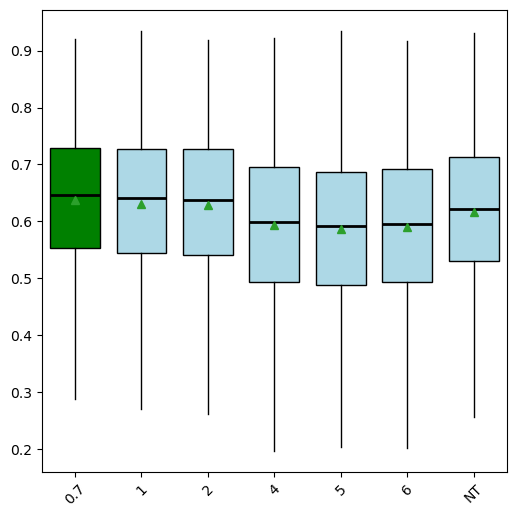

Treat Time 0.7: Mean = 0.6368, Std = 0.1249
Treat Time 1: Mean = 0.6314, Std = 0.1281
Treat Time 2: Mean = 0.6286, Std = 0.1306
Treat Time 4: Mean = 0.5932, Std = 0.1370
Treat Time 5: Mean = 0.5863, Std = 0.1365
Treat Time 6: Mean = 0.5909, Std = 0.1345
Treat Time NT: Mean = 0.6160, Std = 0.1272


In [28]:
# Plot CellObjExp_AreaShape_FormFactor for HU cells with DA treatmode by treat time
import matplotlib.pyplot as plt
import numpy as np

HU_cells_df = per_cells_df[(per_cells_df['CellType'] == 'HU') & (per_cells_df['TreatMode'].isin(['DA']))]
HU_cells_df = HU_cells_df[HU_cells_df['Treat Time'].isin(['NT','0.7','1', '2', '4','5' ,'6'])]
treat_times = HU_cells_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times])
data = []
labels = []
for t in treat_times: 
         temp_df = HU_cells_df[(HU_cells_df['Treat Time'] == str(t))]
         WLR_values = temp_df['CellsObj_AreaShape_MinFeretDiameter'] / temp_df['CellsObj_AreaShape_MaxFeretDiameter']
         data.append(WLR_values)
         labels.append(f'{t}')
print(labels)
plt.figure(figsize=(6, 6))
box = plt.boxplot(data,
            positions=np.arange(1, len(labels) + 1),
            patch_artist=True,
            orientation='vertical', 
            widths=0.75, 
            showmeans=True, 
            showfliers=False,
            showcaps=False,
            medianprops=dict(color='black', linewidth=2))
colours = ['green', 'lightblue','lightblue','lightblue','lightblue','lightblue','lightblue']
for patch, color in zip(box['boxes'], colours):
    patch.set_facecolor(color)

plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=45)
# plt.xticks([])
# plt.yticks([])
# plt.xlabel('Treat Time')
# plt.ylabel('CellObjExp AreaShape FormFactor')
# plt.title('Boxplot of CellObjExp AreaShape FormFactor by Treat Time for HU
# Cells with DA TreatMode')
plt.show()


# Calculate mean and std of CellObjExp_AreaShape_FormFactor for each treat time
for i, t in enumerate(treat_times):
    temp_df = HU_cells_df[(HU_cells_df['Treat Time'] == str(t))]
    WLR_values = temp_df['CellsObj_AreaShape_MinFeretDiameter'] / temp_df['CellsObj_AreaShape_MaxFeretDiameter']
    mean_val = np.mean(WLR_values)
    std_val = np.std(WLR_values)
    print(f'Treat Time {t}: Mean = {mean_val:.4f}, Std = {std_val:.4f}')



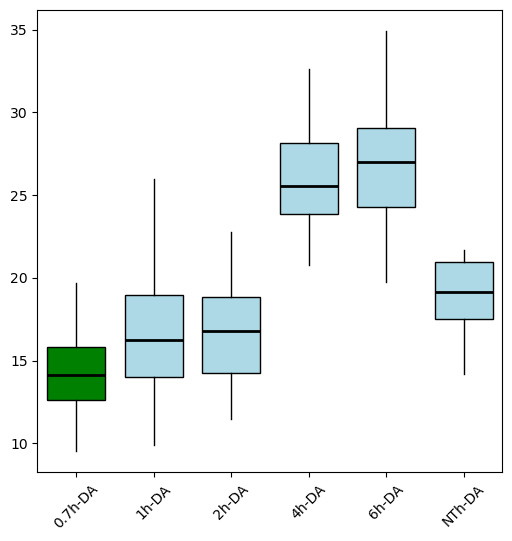

Treat Time 0.7: Mean Percent = 14.64%, Std = 3.34%, Increase vs NT = -4.25% stdev 6.35%
Treat Time 1: Mean Percent = 16.33%, Std = 3.23%, Increase vs NT = -2.57% stdev 6.25%
Treat Time 2: Mean Percent = 16.79%, Std = 2.86%, Increase vs NT = -2.10% stdev 5.87%
Treat Time 4: Mean Percent = 26.06%, Std = 3.14%, Increase vs NT = 7.16% stdev 6.15%
Treat Time 6: Mean Percent = 26.55%, Std = 3.47%, Increase vs NT = 7.66% stdev 6.48%
Treat Time NT: Mean Percent = 18.90%, Std = 3.01%, Increase vs NT = 0.00% stdev 6.02%


In [42]:
# Plot percent/image of HU cells with WLR < 0.5 by treat time
import matplotlib.pyplot as plt
import numpy as np

HU_cells_df = per_cells_df[(per_cells_df['CellType'] == 'HU') & (per_cells_df['TreatMode'].isin(['DA']))]
HU_cells_df = HU_cells_df[HU_cells_df['Treat Time'].isin(['NT','0.7','1', '2', '4','6' ,'24'])]
treat_times = HU_cells_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times])
data = []
labels = []
for t in treat_times:
            temp_df = HU_cells_df[(HU_cells_df['Treat Time'] == str(t))]
            per_image_percents = []
            for img_num, group in temp_df.groupby('ImageNumber'):
                WLR_values = group['CellsObj_AreaShape_MinFeretDiameter'] / group['CellsObj_AreaShape_MaxFeretDiameter']
                percent_below_0_5 = 100.0 * np.sum(WLR_values < 0.5) / len(WLR_values) if len(WLR_values) > 0 else np.nan
                per_image_percents.append(percent_below_0_5)
            data.append(np.array(per_image_percents))
            labels.append(f'{t}h-DA')
plt.figure(figsize=(6, 6))
box = plt.boxplot(data,
            positions=np.arange(1, len(labels) + 1),
            patch_artist=True,
            orientation='vertical', 
            widths=0.75, 
            showmeans=False, 
            showfliers=False,
            showcaps=False,
            medianprops=dict(color='black', linewidth=2))
colours = ['green', 'lightblue','lightblue','lightblue','lightblue','lightblue','lightblue']
for patch, color in zip(box['boxes'], colours):
    patch.set_facecolor(color)  
plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=45)
plt.show()

# Calculate al means and stds of counts above and report % increase of Treatments times vs NT
percent_means = []
percent_stds = []
for i, t in enumerate(treat_times):
    temp_df = HU_cells_df[(HU_cells_df['Treat Time'] == str(t))]
    per_image_percents = []
    for img_num, group in temp_df.groupby('ImageNumber'):
        WLR_values = group['CellsObj_AreaShape_MinFeretDiameter'] / group['CellsObj_AreaShape_MaxFeretDiameter']
        percent_below_0_5 = 100.0 * np.sum(WLR_values < 0.5) / len(WLR_values) if len(WLR_values) > 0 else np.nan
        per_image_percents.append(percent_below_0_5)
    mean_percent = np.nanmean(per_image_percents)
    std_percent = np.nanstd(per_image_percents)
    percent_means.append(mean_percent)
    percent_stds.append(std_percent)
    if t == 'NT':
        nt_mean = mean_percent
        nt_std = std_percent

for i, t in enumerate(treat_times):
    increase = percent_means[i] - nt_mean
    print(f'Treat Time {t}: Mean Percent = {percent_means[i]:.2f}%, Std = {percent_stds[i]:.2f}%, Increase vs NT = {increase:.2f}% stdev {percent_stds[i] + nt_std:.2f}%')


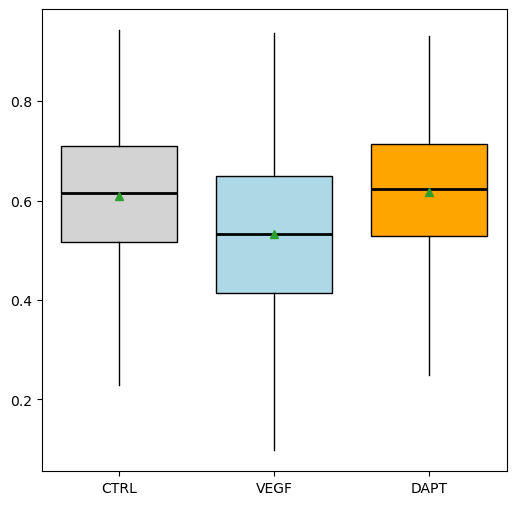

Treat Time CTRL: Mean = 0.6096, Std = 0.1318
Treat Time DAPT: Mean = 0.6178, Std = 0.1282
Treat Time VEGF: Mean = 0.5321, Std = 0.1568


In [3]:
# Plot form factors by treatment IN ECPT data
import matplotlib.pyplot as plt
import numpy as np 

ECPT_HU_df = per_cells_ECPT_df[(per_cells_ECPT_df['CellType'] == 'HUVEC') & (per_cells_ECPT_df['Treat Time'].isin(['CTRL', 'VEGF', 'DAPT']))]
# ECPT_HU_df = ECPT_HU_df[ECPT_HU_df['TreatMode'] == 'D2']
treat_times = ECPT_HU_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times])
data = []
labels = []
for t in treat_times: 
         temp_df = ECPT_HU_df[(ECPT_HU_df['Treat Time'] == str(t))]
         WLR_values = temp_df['CellsObj_AreaShape_MinFeretDiameter'] / temp_df['CellsObj_AreaShape_MaxFeretDiameter']
         #  formfactor_values = temp_df['CellsObj_AreaShape_FormFactor'].values
         data.append(WLR_values)
         labels.append(f'{t}')
# Reorder labels and data to CTRL, VEGF, DAPT
ordered_labels = []
ordered_data = []
for label in ['CTRL', 'VEGF', 'DAPT']:
    if label in labels:
        index = labels.index(label)
        ordered_labels.append(label)
        ordered_data.append(data[index])
plt.figure(figsize=(6, 6))
box = plt.boxplot(ordered_data,
            positions=np.arange(1, len(ordered_labels) + 1),
            patch_artist=True,
            orientation='vertical', 
            widths=0.75, 
            showmeans=True, 
            showfliers=False,
            showcaps=False,
            medianprops=dict(color='black', linewidth=2)
            )
colours = ['lightgrey', 'lightblue','orange']
for patch, color in zip(box['boxes'], colours):
    patch.set_facecolor(color)
plt.xticks(np.arange(1, len(ordered_labels) + 1), ordered_labels)
# plt.xlabel('Treat Time')
# plt.ylabel('CellObjExp AreaShape FormFactor')
# plt.title('Boxplot of CellObjExp AreaShape FormFactor by Treat Time for HUVEC Cells')
plt.show()

# Calculate mean and std of WLR for each treat time
for i, t in enumerate(treat_times):
    temp_df = ECPT_HU_df[(ECPT_HU_df['Treat Time'] == str(t))]
    WLR_values = temp_df['CellsObj_AreaShape_MinFeretDiameter'] / temp_df['CellsObj_AreaShape_MaxFeretDiameter']
    mean_val = np.mean(WLR_values)
    std_val = np.std(WLR_values)
    print(f'Treat Time {t}: Mean = {mean_val:.4f}, Std = {std_val:.4f}')

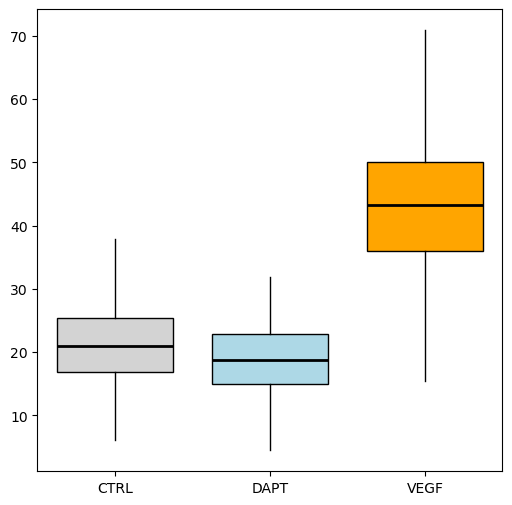

Treat Time CTRL: Mean Percent = 21.57%, Std = 6.58%, Increase vs NT = 0.00% stdev 13.17%
Treat Time DAPT: Mean Percent = 19.51%, Std = 6.32%, Increase vs NT = -2.06% stdev 12.91%
Treat Time VEGF: Mean Percent = 42.80%, Std = 11.39%, Increase vs NT = 21.23% stdev 17.98%


In [43]:
# PLot percent/image of HUVEC cells with WLR < 0.5 by treat time
import matplotlib.pyplot as plt
import numpy as np
ECPT_HU_df = per_cells_ECPT_df[(per_cells_ECPT_df['CellType'] == 'HUVEC') & (per_cells_ECPT_df['Treat Time'].isin(['CTRL', 'VEGF', 'DAPT']))]
treat_times = ECPT_HU_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times])
data = []
labels = []
for t in treat_times:   
            temp_df = ECPT_HU_df[(ECPT_HU_df['Treat Time'] == str(t))]
            per_image_percents = []
            for img_num, group in temp_df.groupby('ImageNumber'):
                WLR_values = group['CellsObj_AreaShape_MinFeretDiameter'] / group['CellsObj_AreaShape_MaxFeretDiameter']
                percent_below_0_5 = 100.0 * np.sum(WLR_values < 0.5) / len(WLR_values) if len(WLR_values) > 0 else np.nan
                per_image_percents.append(percent_below_0_5)
            data.append(np.array(per_image_percents))
            labels.append(f'{t}')
plt.figure(figsize=(6, 6))
box = plt.boxplot(data,
            positions=np.arange(1, len(labels) + 1),
            patch_artist=True,
            orientation='vertical',
            widths=0.75,
            showmeans=False,
            showfliers=False,
            showcaps=False,
            medianprops=dict(color='black', linewidth=2))
colours = ['lightgrey', 'lightblue','orange']
for patch, color in zip(box['boxes'], colours):
    patch.set_facecolor(color)
plt.xticks(np.arange(1, len(labels) + 1), labels)
plt.show()

# Calculate al means and stds of counts above and report % increase of Treatments times vs NT
percent_means = []
percent_stds = []
for i, t in enumerate(treat_times):
    temp_df = ECPT_HU_df[(ECPT_HU_df['Treat Time'] == str(t))]
    per_image_percents = []
    for img_num, group in temp_df.groupby('ImageNumber'):
        WLR_values = group['CellsObj_AreaShape_MinFeretDiameter'] / group['CellsObj_AreaShape_MaxFeretDiameter']
        percent_below_0_5 = 100.0 * np.sum(WLR_values < 0.5) / len(WLR_values) if len(WLR_values) > 0 else np.nan
        per_image_percents.append(percent_below_0_5)
    mean_percent = np.nanmean(per_image_percents)
    std_percent = np.nanstd(per_image_percents)
    percent_means.append(mean_percent)
    percent_stds.append(std_percent)
    if t == 'CTRL':
        nt_mean = mean_percent
        nt_std = std_percent

for i, t in enumerate(treat_times):
    increase = percent_means[i] - nt_mean
    print(f'Treat Time {t}: Mean Percent = {percent_means[i]:.2f}%, Std = {percent_stds[i]:.2f}%, Increase vs NT = {increase:.2f}% stdev {percent_stds[i] + nt_std:.2f}%')



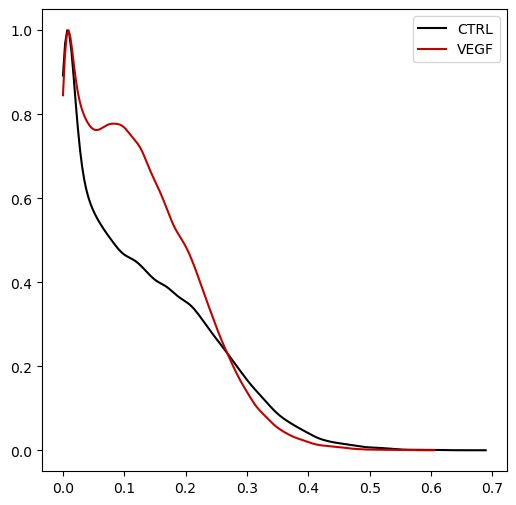

In [9]:
# Plot HES1 KDEs for ECPT HUVECs by treat time
import matplotlib.pyplot as plt
import numpy as np  
import scipy.stats as stats

ECPT_HU_df = per_nuclei_ECPT_df[(per_nuclei_ECPT_df['CellType'] == 'HUVEC') & (per_nuclei_ECPT_df['Treat Time'].isin(['CTRL', 'VEGF', 'DAPT']))]
treat_times = ECPT_HU_df['Treat Time'].unique()
treat_times = sorted([str(t) for t in treat_times])
data = []
labels = []
for t in treat_times:
     temp_df = ECPT_HU_df[(ECPT_HU_df['Treat Time'] == str(t))]
     hes_values = temp_df['Nuclei_Intensity_MeanIntensity_HEST'].values
     data.append(hes_values)
     labels.append(f'{t}')
# Reorder labels and data to CTRL, VEGF, DAPT
ordered_labels = []
ordered_data = []
for label in ['CTRL', 'VEGF']:
    if label in labels:
        index = labels.index(label)
        ordered_labels.append(label)
        ordered_data.append(data[index])
plt.figure(figsize=(6, 6))
for i, hes_values in enumerate(ordered_data):
    density = stats.gaussian_kde(hes_values)
    xs = np.linspace(min(hes_values), max(hes_values), 200)
    ys = density(xs)
    ys_scaled = ys / ys.max()  # Scale to 0-1
    plt.plot(xs, ys_scaled, label=ordered_labels[i], color=plt.cm.gist_heat(i / len(ordered_data))) 
# plt.xticks([])
# plt.yticks([])
# plt.xlabel('Nuclei Intensity Mean Intensity HES')
# plt.ylabel('Density')
# plt.title('Density Distributions of HES Values by Treat Time for HUVEC Cells')
plt.legend()
plt.show()

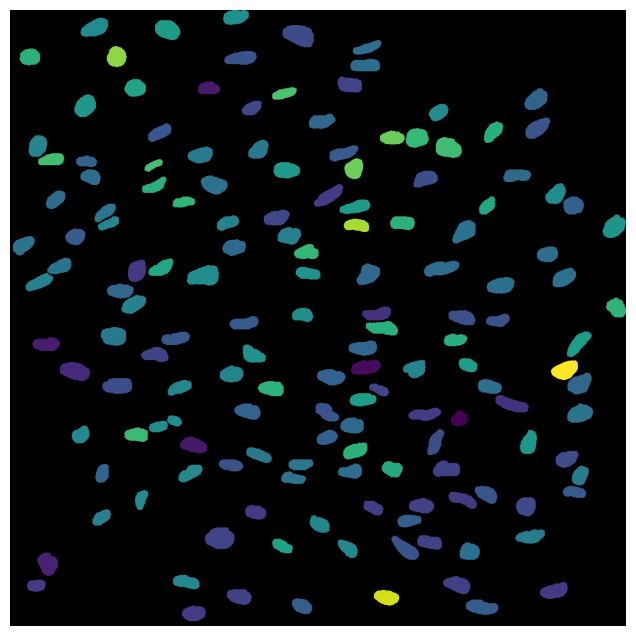

In [4]:
import numpy as np
import pandas as pd
from skimage import measure
import matplotlib.pyplot as plt

image_path = '/Users/lory/Desktop/MANUSCRIPTS/1_Chesnais_et_al_2022_NOTCH Modelling/Aortas/aorta2_raw_img.txt'
image_data_path = '/Users/lory/Desktop/MANUSCRIPTS/1_Chesnais_et_al_2022_NOTCH Modelling/Aortas/Results_A2_for_plot.csv'

# Read the image data from the text file into a 2D numpy array
image_data = np.loadtxt(image_path)
image_data[image_data == 0] = 1  # Set region pixels to 1
image_data[image_data == 255] = 0  # Set background pixels to 0

# Load the CSV data into a pandas DataFrame
csv_df = pd.read_csv(image_data_path)
mean_values = csv_df['Mean'].values

# Label the nuclei regions (use a threshold if needed)
regions = measure.label(image_data)
# print(np.unique(regions))
# Get region properties
props = measure.regionprops(regions)

# Normalize mean values to 0-1
min_mean = mean_values.min()
max_mean = mean_values.max()
normalized_means = (mean_values - min_mean) / (max_mean - min_mean)
# print(normalized_means)
# Create a colormap
cmap = plt.get_cmap('viridis')

# Create an RGB image to hold the colorized regions
colourised_image = np.zeros((*regions.shape, 3), dtype=np.float32)

# for i, region_label in enumerate(np.unique(regions)):
#     if region_label == 1:
#         continue  # Skip background
#     if i-1 < len(normalized_means):
#         colour = cmap(normalized_means[i-1])[:3]  # Get RGB color
#         coords = np.argwhere(regions == region_label)
#         for coord in coords:
#             colourised_image[coord[0], coord[1], :] = colour

# Color each region according to its normalized mean value
for i, prop in enumerate(props):
    if i < len(normalized_means):
        colour = cmap(normalized_means[i])[:3]  # Get RGB color
        coords = prop.coords
        # Find all pixels internal to the region
        for coord in coords:
            colourised_image[coord[0], coord[1], :] = colour
                
        # print('plotted region', i+1)


# Display the colorized image
plt.figure(figsize=(8, 8))
plt.imshow(colourised_image)  # Show colorized regions
plt.axis('off')
# plt.title('Colourised Nuclei Regions by Mean Intensity')
plt.show()

In [ ]:
# Scatterplot of HES values for sparse HUVECs by treat time with consistent colour scale
import matplotlib.pyplot as plt
import numpy as np

HU_df = per_nuclei_Sparse_df[per_nuclei_Sparse_df['CellType'] == 'HUVEC'].copy()
HU_df = HU_df[HU_df['Treat Time'].isin(['CTRL'])]
# Drop images with more than 8 entries
image_counts = HU_df['ImageNumber'].value_counts()
images_to_keep = image_counts[image_counts <= 8].index
HU_df = HU_df[HU_df['ImageNumber'].isin(images_to_keep)]

treat_times = sorted(HU_df['Treat Time'].astype(str).unique())
pos_map = {t: i for i, t in enumerate(treat_times)}

# Shared colour normalization across all points so identical ImageNumber gets identical colour
img_numbers = HU_df['ImageNumber'].values
norm = plt.Normalize(vmin=img_numbers.min(), vmax=img_numbers.max())
cmap = plt.cm.Set1

fig, ax = plt.subplots(figsize=(6, 5))
for t in treat_times:
    temp_df = HU_df[HU_df['Treat Time'] == t]
    hes_values = temp_df['Nuclei_Intensity_MeanIntensity_HES'].values
    jittered_x = np.random.normal(loc=pos_map[t], scale=0.05, size=len(hes_values))
    ax.scatter(jittered_x, hes_values, label=f'{t}', c=temp_df['ImageNumber'].values,
               cmap=cmap, norm=norm, alpha=0.7, edgecolors='k', linewidths=0.25, s=10)

# Confluent HUVEC control for reference
confluent_df = per_nuclei_df[(per_nuclei_df['CellType'] == 'HUVEC') & (per_nuclei_df['Treat Time'] == 'NT')]
confluent_hes = confluent_df['Nuclei_Intensity_MeanIntensity_HES'].values
jittered_x = np.random.normal(loc=-0.6, scale=0.05, size=len(confluent_hes))
ax.scatter(jittered_x, confluent_hes, label='Confluent NT', c='gray', alpha=0.7, edgecolors='k', linewidths=0.25, s=10)

ax.set_xticks([-0.6] + list(pos_map.values()))
ax.set_xticklabels(['Confluent NT'] + list(pos_map.keys()), rotation=45, ha='right')
ax.set_xlabel('Treat Time')
ax.set_ylabel('Nuclei_Intensity_MeanIntensity_HES')
ax.legend(title='Treat Time', loc='upper right')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='ImageNumber')
fig.tight_layout()
plt.show()
